# Chen-Shen 2022 Fig. 5 / Fig. 6: GLOF Projection Check

This notebook verifies the pure GLOF projection calculation, without Fourier post-processing. It reproduces the examples shown in Fig. 5 and Fig. 6 of

`Lit_Lib/Log Singularity/Chen和Shen_-_2022_-_Log_orthogonal_functions_approximation_properties_and_applications_2058863804864536576.md`.

The figures use `alpha=lambda=0`, hence the error is the usual unweighted `L2(0,1)` projection error.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from mpmath import mp

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / "GLOF_Python").exists() else cwd.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from GLOF_Python.glof_reconstruction import (
    glof_basis_matrix,
    glof_coefficients,
    glof_normalization,
    glof_quadrature,
)

mp.dps = 100
print(f"repo_root = {repo_root}")
print(f"mp.dps = {mp.dps}")

repo_root = /Users/zcq/PaperCode/Recover
mp.dps = 100


## Examples Read From The Paper Figure Legends

- Fig. 5 left: `beta=3`, `r=0.1,0.3,0.5,0.7,0.9`, `k=0`.
- Fig. 5 right: `beta=7`, `r=10,20,30,40,50`, `k=0`.
- Fig. 6 left: `beta=5`, `r=1`, `k=1,2,3,4,5`.
- Fig. 6 right: `beta=5`, `r=2`, `k=1,2,3,4,5`.

All use `alpha=lambda=0`.

## Exact Coefficients and Exact Tail Error

For `f(t)=t^r(-log t)^k`, `alpha=lambda=0`, and GLOF parameter `beta`, the coefficient can be computed in the Laguerre variable. The implementation below uses the direct Rodrigues expansion of

$$\int_0^\infty e^{-s y} y^k L_n(y)\,dy,$$

with `s=(beta+2r+2)/(2(beta+1))`. The projection error is then computed from the orthogonal tail

$$\|f-\pi_N f\|^2=\sum_{n=N+1}^{\infty} |c_n|^2\gamma_n,$$

where for `alpha=0`, `gamma_n=1/(beta+1)`.

In [2]:
def model_value(t, r, k):
    t = mp.mpf(t)
    r = mp.mpf(r)
    k = int(k)
    if t == 0:
        return mp.zero
    if t == 1:
        return mp.one if k == 0 else mp.zero
    return mp.power(t, r) * mp.power(-mp.log(t), k)


def exact_glof_coeff_model(n, r, k, beta):
    """Exact coefficient for alpha=lambda=0 and f=t^r(-log t)^k."""
    n = int(n)
    k = int(k)
    r = mp.mpf(r)
    beta = mp.mpf(beta)
    s = (beta + 2 * r + 2) / (2 * (beta + 1))

    total = mp.zero
    for j in range(min(k, n) + 1):
        total += (
            mp.factorial(k)
            * mp.gamma(n - j + k + 1)
            / (mp.factorial(j) * mp.factorial(k - j) * mp.gamma(n - j + 1))
            * mp.power(1 - s, n - j)
            / mp.power(s, n - j + k + 1)
        )

    return mp.power(-1, n) * mp.power(beta + 1, -k) * total


def exact_l2_tail_error(N, r, k, beta, rel_stop="1e-80", max_terms=5000):
    """Exact L2 projection error from the orthogonal coefficient tail."""
    N = int(N)
    beta = mp.mpf(beta)
    gamma_n = 1 / (beta + 1)
    tail = mp.zero
    small_count = 0
    rel_stop = mp.mpf(rel_stop)

    for n in range(N + 1, max_terms):
        c_n = exact_glof_coeff_model(n, r, k, beta)
        term = c_n * c_n * gamma_n
        tail += term
        if n > N + 20 and tail != 0 and abs(term) < abs(tail) * rel_stop:
            small_count += 1
            if small_count >= 10:
                break
        else:
            small_count = 0

    return mp.sqrt(max(tail, mp.zero))


def log10_errors(N_values, r, k, beta, floor=-16.2):
    logs = []
    raw = []
    for N in N_values:
        err = exact_l2_tail_error(N, r, k, beta)
        raw.append(err)
        logs.append(max(float(mp.log10(err)), floor) if err > 0 else floor)
    return logs, raw

## Cross-Check: Numerical Gauss-GLOF Projection vs Exact Coefficients

This checks the implementation used in `glof_reconstruction.py`: GLOF quadrature nodes/weights, basis matrix, normalization, and coefficient assembly.

In [3]:
def quadrature_projection_coefficients(r, k, beta, N, Q):
    quad = glof_quadrature(alpha=0, beta=beta, lambda_value=0, q=Q)
    phi = glof_basis_matrix(quad.x, quad.y, alpha=0, beta=beta, lambda_value=0, m=N)
    gamma_l = glof_normalization(alpha=0, beta=beta, m=N)
    f_values = [model_value(t, r, k) for t in quad.x]
    return glof_coefficients(f_values, phi, quad.chi, gamma_l)


checks = [
    {"beta": 3, "r": "0.5", "k": 0, "N": 20, "Q": 160},
    {"beta": 5, "r": 1, "k": 3, "N": 25, "Q": 200},
    {"beta": 7, "r": 20, "k": 0, "N": 40, "Q": 300},
]

print(" beta     r   k    N    Q     max |c_quad - c_exact|")
for case in checks:
    c_quad = quadrature_projection_coefficients(**case)
    c_exact = [exact_glof_coeff_model(n, case["r"], case["k"], case["beta"]) for n in range(case["N"] + 1)]
    max_diff = max(abs(c_quad[n] - c_exact[n]) for n in range(case["N"] + 1))
    print(f"{case['beta']:5} {str(case['r']):>5} {case['k']:3d} {case['N']:4d} {case['Q']:4d}   {mp.nstr(max_diff, 12)}")

 beta     r   k    N    Q     max |c_quad - c_exact|
    3   0.5   0   20  160   1.82163615486e-100
    5     1   3   25  200   5.00056983686e-100
    7    20   0   40  300   1.71197280794e-100


## Fig. 5 Reproduction

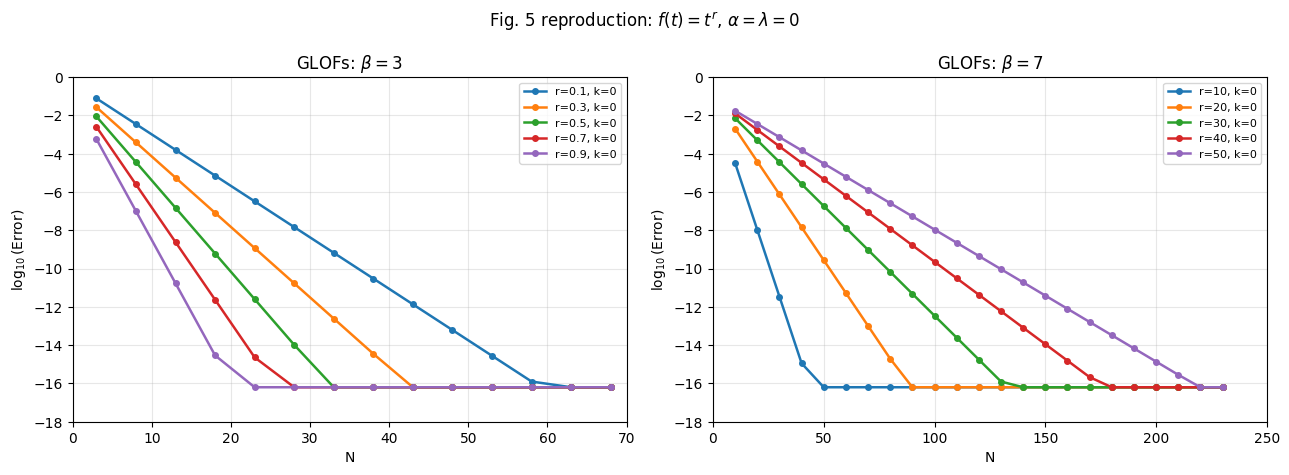

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

beta = 3
N_values = list(range(3, 71, 5))
for r in ["0.1", "0.3", "0.5", "0.7", "0.9"]:
    logs, _ = log10_errors(N_values, r=r, k=0, beta=beta)
    axes[0].plot(N_values, logs, "o-", linewidth=1.8, markersize=4, label=f"r={r}, k=0")
axes[0].set_title(r"GLOFs: $\beta=3$")
axes[0].set_xlabel("N")
axes[0].set_ylabel(r"$\log_{10}(\mathrm{Error})$")
axes[0].set_xlim(0, 70)
axes[0].set_ylim(-18, 0)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

beta = 7
N_values = list(range(10, 231, 10))
for r in [10, 20, 30, 40, 50]:
    logs, _ = log10_errors(N_values, r=r, k=0, beta=beta)
    axes[1].plot(N_values, logs, "o-", linewidth=1.8, markersize=4, label=f"r={r}, k=0")
axes[1].set_title(r"GLOFs: $\beta=7$")
axes[1].set_xlabel("N")
axes[1].set_ylabel(r"$\log_{10}(\mathrm{Error})$")
axes[1].set_xlim(0, 250)
axes[1].set_ylim(-18, 0)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.suptitle(r"Fig. 5 reproduction: $f(t)=t^r$, $\alpha=\lambda=0$")
plt.tight_layout()
plt.show()

## Fig. 6 Reproduction

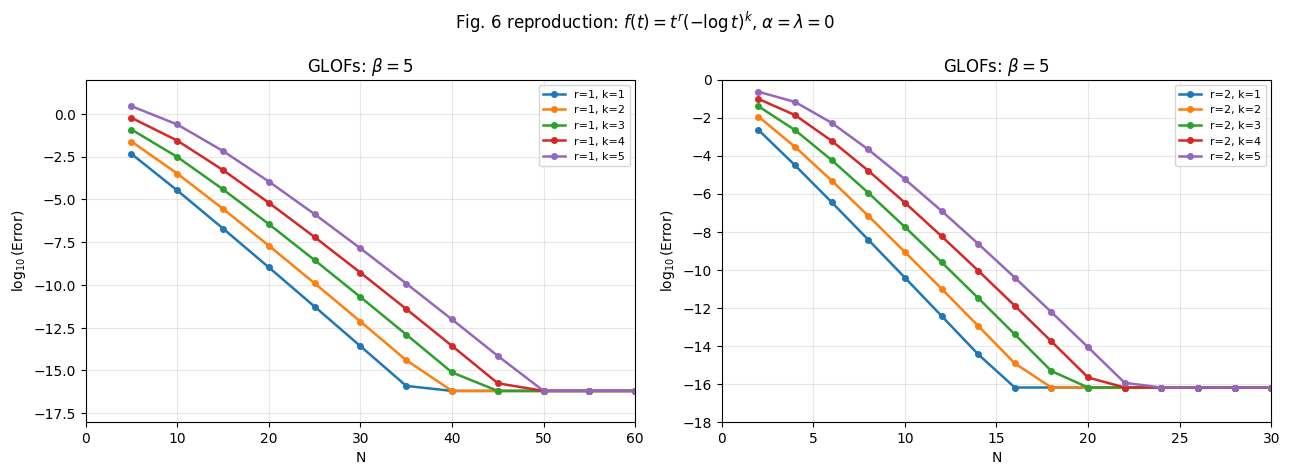

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

beta = 5
N_values = list(range(5, 61, 5))
for k in [1, 2, 3, 4, 5]:
    logs, _ = log10_errors(N_values, r=1, k=k, beta=beta)
    axes[0].plot(N_values, logs, "o-", linewidth=1.8, markersize=4, label=f"r=1, k={k}")
axes[0].set_title(r"GLOFs: $\beta=5$")
axes[0].set_xlabel("N")
axes[0].set_ylabel(r"$\log_{10}(\mathrm{Error})$")
axes[0].set_xlim(0, 60)
axes[0].set_ylim(-18, 2)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

N_values = list(range(2, 31, 2))
for k in [1, 2, 3, 4, 5]:
    logs, _ = log10_errors(N_values, r=2, k=k, beta=beta)
    axes[1].plot(N_values, logs, "o-", linewidth=1.8, markersize=4, label=f"r=2, k={k}")
axes[1].set_title(r"GLOFs: $\beta=5$")
axes[1].set_xlabel("N")
axes[1].set_ylabel(r"$\log_{10}(\mathrm{Error})$")
axes[1].set_xlim(0, 30)
axes[1].set_ylim(-18, 0)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.suptitle(r"Fig. 6 reproduction: $f(t)=t^r(-\log t)^k$, $\alpha=\lambda=0$")
plt.tight_layout()
plt.show()

## Numerical Values For Quick Regression Checks

In [6]:
regression_points = [
    ("Fig5-left", 3, "0.1", 0, 40),
    ("Fig5-left", 3, "0.9", 0, 25),
    ("Fig5-right", 7, 10, 0, 50),
    ("Fig5-right", 7, 50, 0, 220),
    ("Fig6-left", 5, 1, 1, 35),
    ("Fig6-left", 5, 1, 5, 45),
    ("Fig6-right", 5, 2, 1, 18),
    ("Fig6-right", 5, 2, 5, 22),
]

print("case        beta     r   k    N     error           log10(error)")
for name, beta, r, k, N in regression_points:
    err = exact_l2_tail_error(N, r, k, beta)
    print(f"{name:10} {beta:5} {str(r):>5} {k:3d} {N:4d}   {mp.nstr(err, 12):>14}   {mp.nstr(mp.log10(err), 10):>12}")

case        beta     r   k    N     error           log10(error)
Fig5-left      3   0.1   0   40   8.66466094266e-12   -11.06224843
Fig5-left      3   0.9   0   25   1.54846591908e-20   -19.81009835
Fig5-right     7    10   0   50   3.69575716405e-19   -18.43229657
Fig5-right     7    50   0  220   5.77184817413e-17    -16.2386851
Fig6-left      5     1   1   35   1.24379200171e-16   -15.90525224
Fig6-left      5     1   5   45   6.97981283131e-15   -14.15615622
Fig6-right     5     2   1   18   3.0459402893e-19   -18.51627861
Fig6-right     5     2   5   22   1.11278069594e-16   -15.95359042
